In [108]:
# =========================
# MedPredict Pro
# Intelligent Diabetes Risk Analysis System
# =========================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [109]:
# Load Dataset
df = pd.read_csv("diabetes.csv")

# Show first rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [110]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [111]:
# Statistical Summary
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [112]:
# Missing Values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

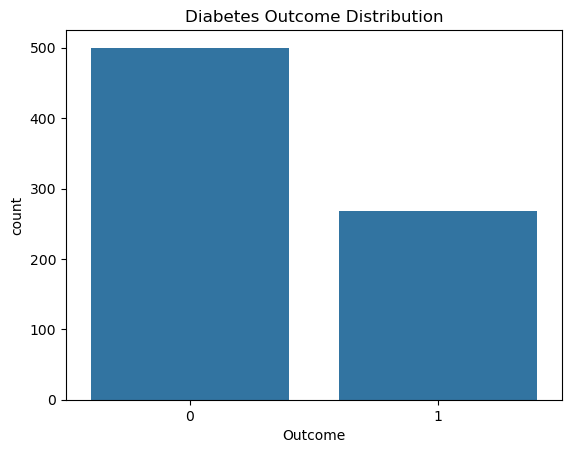

In [113]:
# Diabetes Outcome Count

sns.countplot(x='Outcome', data=df)

plt.title("Diabetes Outcome Distribution")
plt.show()

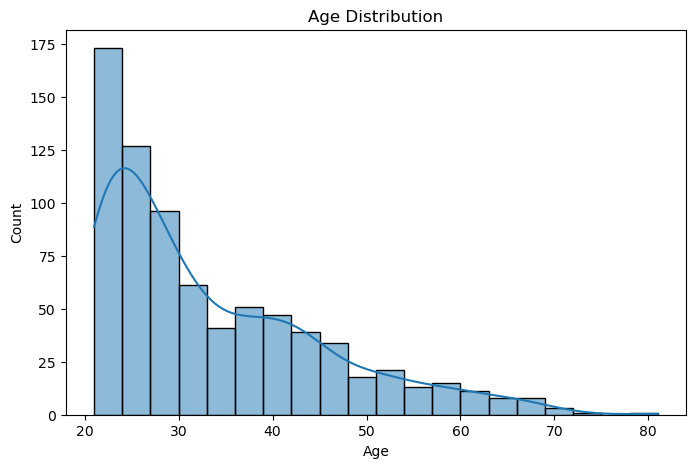

In [114]:
# Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.show()

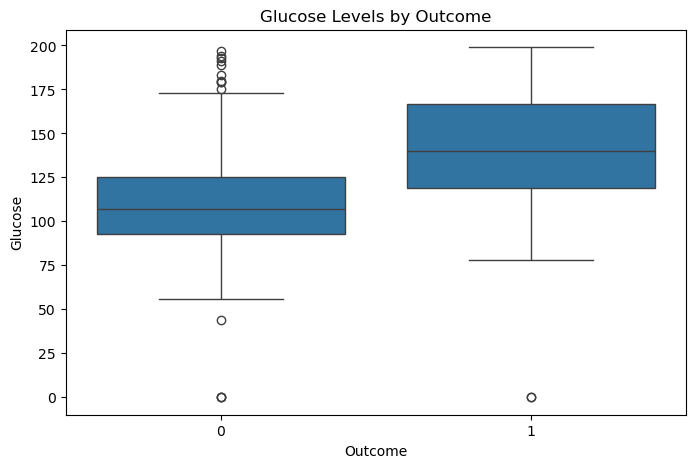

In [115]:
# Glucose vs Outcome

plt.figure(figsize=(8,5))

sns.boxplot(x='Outcome', y='Glucose', data=df)

plt.title("Glucose Levels by Outcome")
plt.show()

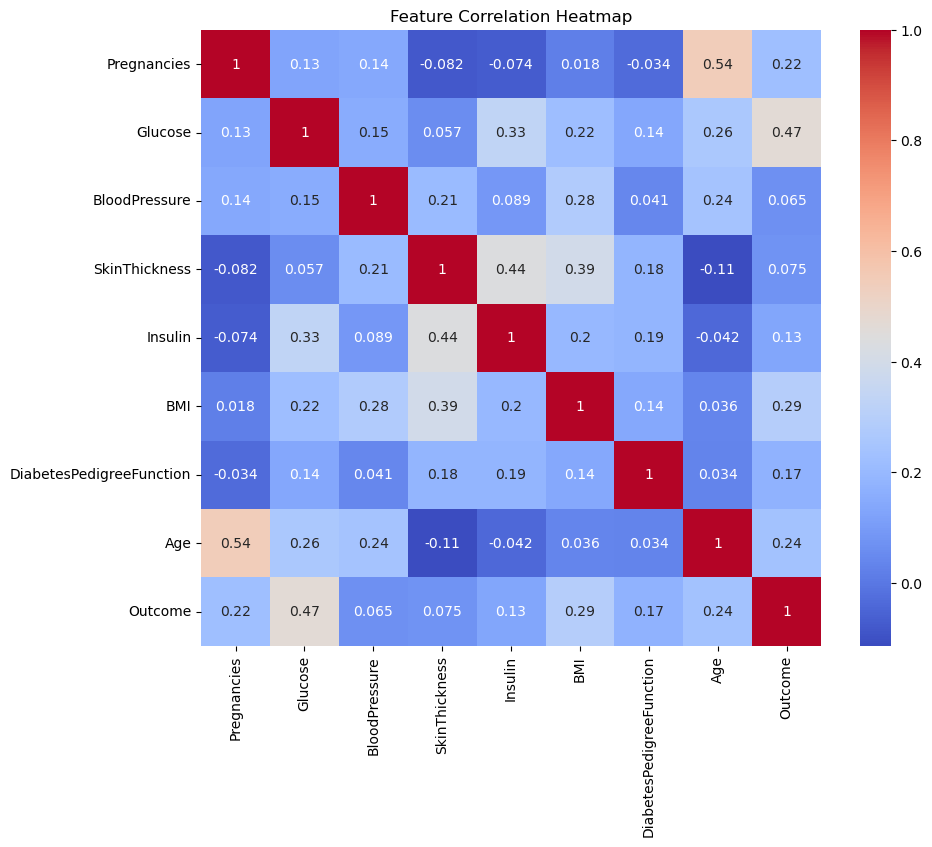

In [116]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

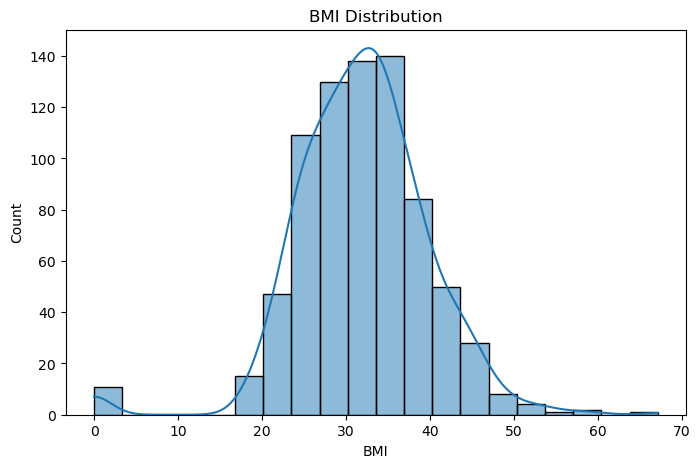

In [117]:
# BMI Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['BMI'], bins=20, kde=True)

plt.title("BMI Distribution")

plt.show()

In [118]:
# Columns that should not contain zero values

columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns:
    
    # Replace zeros with NaN
    df[col] = df[col].replace(0, np.nan)
    
    # Fill missing values with median
    df[col].fillna(df[col].median(), inplace=True)

In [119]:
# Handle missing values

imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [120]:
# Features
X = df.drop("Outcome", axis=1)

# Target
y = df["Outcome"]

In [121]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [122]:
# Logistic Regression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_acc = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.7532467532467533


In [123]:
# Decision Tree

tree_model = DecisionTreeClassifier()

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_acc = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_acc)

Decision Tree Accuracy: 0.7142857142857143


In [124]:
# Random Forest

forest_model = RandomForestClassifier()

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

forest_acc = accuracy_score(y_test, forest_pred)

print("Random Forest Accuracy:", forest_acc)

Random Forest Accuracy: 0.7662337662337663


In [125]:
# Compare Models

models = ['Logistic Regression', 'Decision Tree', 'Random Forest']

accuracies = [log_acc, tree_acc, forest_acc]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.753247
1,Decision Tree,0.714286
2,Random Forest,0.766234


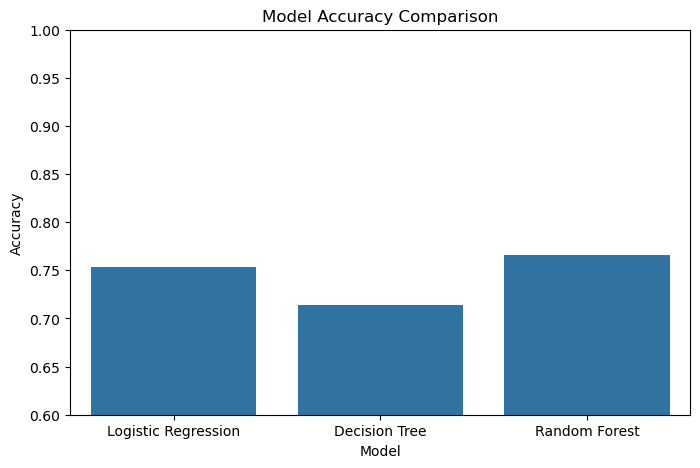

In [126]:
# Accuracy Comparison Chart

plt.figure(figsize=(8,5))

sns.barplot(x='Model', y='Accuracy', data=comparison_df)

plt.title("Model Accuracy Comparison")

plt.ylim(0.6, 1.0)

plt.show()

In [127]:
# Feature Importance

importance = forest_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Feature,Importance
1,Glucose,0.255742
5,BMI,0.162336
7,Age,0.141628
6,DiabetesPedigreeFunction,0.115962
4,Insulin,0.089926
2,BloodPressure,0.084012
0,Pregnancies,0.075857
3,SkinThickness,0.074537


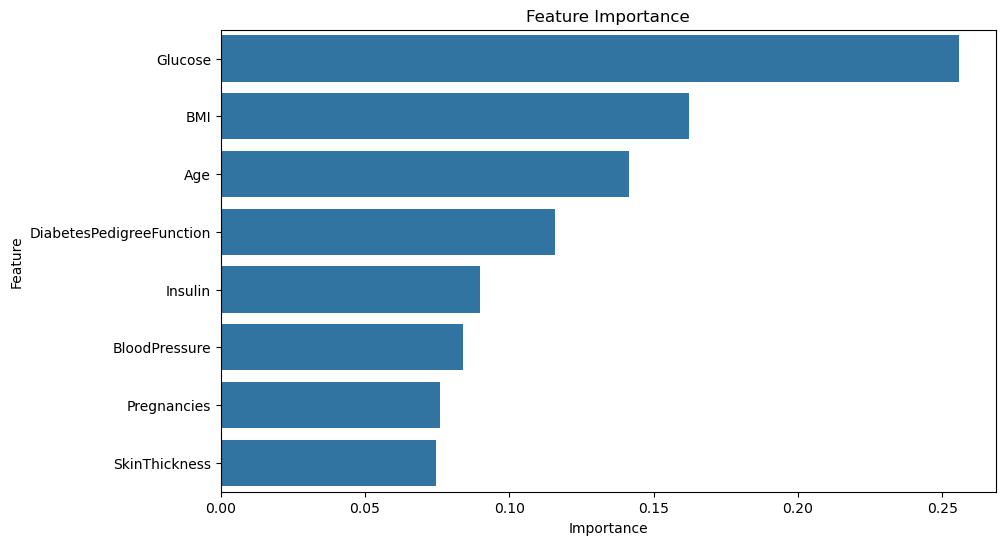

In [128]:
# Plot Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Feature Importance")

plt.show()

In [129]:
# Explainable AI Function

def explain_prediction(input_data):

    explanations = []

    if input_data['Glucose'] > 140:
        explanations.append("High glucose level detected")

    if input_data['BMI'] > 30:
        explanations.append("BMI indicates obesity risk")

    if input_data['Age'] > 45:
        explanations.append("Age increases diabetes risk")

    if input_data['BloodPressure'] > 85:
        explanations.append("High blood pressure detected")

    return explanations

In [130]:
sample_patient = {
    'Glucose': 180,
    'BMI': 35,
    'Age': 50,
    'BloodPressure': 90
}

explain_prediction(sample_patient)

['High glucose level detected',
 'BMI indicates obesity risk',
 'Age increases diabetes risk',
 'High blood pressure detected']

In [131]:
sample_patient = {
    'Glucose': 900,
    'BMI': 35,
    'Age': 30,
    'BloodPressure': 90
}

explain_prediction(sample_patient)

['High glucose level detected',
 'BMI indicates obesity risk',
 'High blood pressure detected']

In [132]:
# Professional Prediction Function

def predict_diabetes(patient_data):

    # Convert to DataFrame
    patient_df = pd.DataFrame([patient_data])

    # Apply imputer
    patient_df = imputer.transform(patient_df)

    # Prediction
    prediction = forest_model.predict(patient_df)[0]

    # Prediction Probability
    probability = forest_model.predict_proba(patient_df)[0][1]
   
    confidence = round(
    max(probability, 1 - probability) * 100,
    2
)

    # Risk Percentage
    risk_percent = round(probability * 100, 2)

    # Risk Level
    if risk_percent < 30:
        risk_level = "Low Risk 🟢"

    elif risk_percent < 70:
        risk_level = "Medium Risk 🟡"

    else:
        risk_level = "High Risk 🔴"

    # Explanation
    explanation = explain_prediction(patient_data)

    # Result
    result = {

    "Prediction": "Diabetic" if prediction == 1 else "Non-Diabetic",

    "Risk Percentage": risk_percent,

    "Risk Level": risk_level,

    "Explanation": explanation
}
    return result
    

In [133]:
# Example Patient

patient = {
    'Pregnancies': 2,
    'Glucose': 180,
    'BloodPressure': 90,
    'SkinThickness': 35,
    'Insulin': 200,
    'BMI': 38.5,
    'DiabetesPedigreeFunction': 0.8,
    'Age': 50
}

result = predict_diabetes(patient)

print(" Diabetes Prediction Report")
print()

print(f"📊 Risk Percentage: {result['Risk Percentage']}%")

print(f"🚨 Risk Level: {result['Risk Level']}")

print()

print("🔍 AI Medical Explanation")

for reason in result["Explanation"]:

    print(f"✅ {reason}")

 Diabetes Prediction Report

📊 Risk Percentage: 97.0%
🚨 Risk Level: High Risk 🔴

🔍 AI Medical Explanation
✅ High glucose level detected
✅ BMI indicates obesity risk
✅ Age increases diabetes risk
✅ High blood pressure detected


In [134]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    PageBreak
)

from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from datetime import datetime

In [135]:
def generate_pdf_report(patient, result):

    file_name = "Diabetes_Report.pdf"

    doc = SimpleDocTemplate(file_name)

    styles = getSampleStyleSheet()

    content = []

    # =========================
    # Title
    # =========================

    title = Paragraph(
        "MEDVISION AI - Diabetes Risk Report",
        styles['Title']
    )

    content.append(title)

    content.append(Spacer(1, 20))

    # =========================
    # Date
    # =========================

    date_text = Paragraph(
        f"Generated: {datetime.now()}",
        styles['Normal']
    )

    content.append(date_text)

    content.append(Spacer(1, 20))

    # =========================
    # Patient Data
    # =========================

    content.append(
        Paragraph(
            "Patient Information",
            styles['Heading2']
        )
    )

    for key, value in patient.items():

        content.append(
            Paragraph(
                f"{key}: {value}",
                styles['Normal']
            )
        )

    content.append(Spacer(1, 20))

    # =========================
    # Prediction Result
    # =========================

    content.append(
        Paragraph(
            "Prediction Result",
            styles['Heading2']
        )
    )

    content.append(
        Paragraph(
            f"Prediction: {result['Prediction']}",
            styles['Normal']
        )
    )

    content.append(
        Paragraph(
            f"Risk Percentage: {result['Risk Percentage']}%",
            styles['Normal']
        )
    )

    content.append(
        Paragraph(
            f"Risk Level: {result['Risk Level']}",
            styles['Normal']
        )
    )


    content.append(Spacer(1, 20))

    # =========================
    # AI Insights
    # =========================

    content.append(
        Paragraph(
            "AI Medical Insights",
            styles['Heading2']
        )
    )

    for item in result["Explanation"]:

        content.append(
            Paragraph(
                f"• {item}",
                styles['Normal']
            )
        )

    content.append(Spacer(1, 20))

    # =========================
    # Footer
    # =========================

    footer = Paragraph(
        "Generated by MedVision AI",
        styles['Italic']
    )

    content.append(footer)

    doc.build(content)

    return file_name

In [136]:
result = predict_diabetes(patient)

pdf_file = generate_pdf_report(
    patient,
    result
)

print("PDF Created Successfully")

PDF Created Successfully
